In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import GroupShuffleSplit

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

import joblib

In [4]:
import xgboost as xgb

In [5]:
BASE_DIR = Path.cwd().parent

PROCESSED_DATA_PATH = (
    BASE_DIR
    / "Data"
    / "Processed"
    / "diabetic_data_processed.csv"
)

df = pd.read_csv(
    PROCESSED_DATA_PATH
)

print("Dataset loaded successfully.")

print(
    "Rows:",
    df.shape[0]
)

print(
    "Columns:",
    df.shape[1]
)

Dataset loaded successfully.
Rows: 101766
Columns: 50


In [6]:
df["readmitted"].value_counts()

readmitted
0    54864
1    46902
Name: count, dtype: int64

In [7]:
df["readmitted"].value_counts(
    normalize=True
) * 100

readmitted
0    53.911916
1    46.088084
Name: proportion, dtype: float64

In [8]:
print(
    "Total encounters:",
    len(df)
)

print(
    "Unique patients:",
    df["patient_nbr"].nunique()
)

print(
    "Repeated patient IDs:",
    df["patient_nbr"].duplicated().sum()
)

Total encounters: 101766
Unique patients: 71518
Repeated patient IDs: 30248


In [9]:
demographic_features = [
    "race",
    "gender",
    "age"
]

In [10]:
hospital_features = [
    "time_in_hospital",
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id"
]

In [11]:
utilization_features = [
    "number_outpatient",
    "number_emergency",
    "number_inpatient"
]

In [12]:
clinical_features = [
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_diagnoses"
]

In [13]:
diabetes_features = [
    "diabetesMed",
    "insulin",
    "A1Cresult_available",
    "max_glu_serum_available"
]

In [14]:
feature_columns = (
    demographic_features
    + hospital_features
    + utilization_features
    + clinical_features
    + diabetes_features
)

print(
    "Number of features:",
    len(feature_columns)
)

print(
    feature_columns
)

Number of features: 18
['race', 'gender', 'age', 'time_in_hospital', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'number_outpatient', 'number_emergency', 'number_inpatient', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_diagnoses', 'diabetesMed', 'insulin', 'A1Cresult_available', 'max_glu_serum_available']


In [15]:
X = df[
    feature_columns
].copy()

y = df[
    "readmitted"
].copy()

groups = df[
    "patient_nbr"
].copy()

In [16]:
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(
        X,
        y,
        groups=groups
    )
)

In [17]:
X_train = X.iloc[
    train_idx
]

X_test = X.iloc[
    test_idx
]

y_train = y.iloc[
    train_idx
]

y_test = y.iloc[
    test_idx
]

groups_train = groups.iloc[
    train_idx
]

groups_test = groups.iloc[
    test_idx
]

In [18]:
overlap = set(
    groups_train
).intersection(
    set(groups_test)
)

print(
    "Number of patients appearing in both sets:",
    len(overlap)
)

Number of patients appearing in both sets: 0


In [19]:
print(
    "Training rows:",
    X_train.shape[0]
)

print(
    "Testing rows:",
    X_test.shape[0]
)

Training rows: 81613
Testing rows: 20153


In [20]:
print(
    "Training target distribution:"
)

print(
    y_train.value_counts(
        normalize=True
    ) * 100
)

print(
    "\nTesting target distribution:"
)

print(
    y_test.value_counts(
        normalize=True
    ) * 100
)

Training target distribution:
readmitted
0    53.729185
1    46.270815
Name: proportion, dtype: float64

Testing target distribution:
readmitted
0    54.651913
1    45.348087
Name: proportion, dtype: float64


In [21]:
X_train.dtypes

race                          str
gender                        str
age                           str
time_in_hospital            int64
admission_type_id           int64
discharge_disposition_id    int64
admission_source_id         int64
number_outpatient           int64
number_emergency            int64
number_inpatient            int64
num_lab_procedures          int64
num_procedures              int64
num_medications             int64
number_diagnoses            int64
diabetesMed                   str
insulin                       str
A1Cresult_available         int64
max_glu_serum_available     int64
dtype: object

In [22]:
categorical_features = (
    X_train
    .select_dtypes(
        include=["object"]
    )
    .columns
    .tolist()
)

numerical_features = (
    X_train
    .select_dtypes(
        exclude=["object"]
    )
    .columns
    .tolist()
)

print(
    "Categorical features:"
)

print(
    categorical_features
)

print(
    "\nNumerical features:"
)

print(
    numerical_features
)

Categorical features:
['race', 'gender', 'age', 'diabetesMed', 'insulin']

Numerical features:
['time_in_hospital', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'number_outpatient', 'number_emergency', 'number_inpatient', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_diagnoses', 'A1Cresult_available', 'max_glu_serum_available']


C:\Users\Sai\AppData\Local\Temp\ipykernel_17780\1405367331.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  .select_dtypes(


In [23]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        )
    ]
)

In [24]:
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [25]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [26]:
logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced"
            )
        )
    ]
)

In [27]:
print(
    "Training Logistic Regression..."
)

logistic_model.fit(
    X_train,
    y_train
)

print(
    "Training completed."
)

Training Logistic Regression...
Training completed.


In [28]:
y_pred_logistic = (
    logistic_model.predict(
        X_test
    )
)

y_prob_logistic = (
    logistic_model.predict_proba(
        X_test
    )[:, 1]
)

In [29]:
logistic_metrics = {
    "Model": "Logistic Regression",

    "Accuracy": accuracy_score(
        y_test,
        y_pred_logistic
    ),

    "Precision": precision_score(
        y_test,
        y_pred_logistic
    ),

    "Recall": recall_score(
        y_test,
        y_pred_logistic
    ),

    "F1": f1_score(
        y_test,
        y_pred_logistic
    ),

    "ROC_AUC": roc_auc_score(
        y_test,
        y_prob_logistic
    )
}

logistic_metrics

{'Model': 'Logistic Regression',
 'Accuracy': 0.6208504937230189,
 'Precision': 0.5931128791645948,
 'Recall': 0.5220483641536273,
 'F1': 0.5553163009951696,
 'ROC_AUC': 0.657233600153138}

In [30]:
print(
    classification_report(
        y_test,
        y_pred_logistic
    )
)

              precision    recall  f1-score   support

           0       0.64      0.70      0.67     11014
           1       0.59      0.52      0.56      9139

    accuracy                           0.62     20153
   macro avg       0.62      0.61      0.61     20153
weighted avg       0.62      0.62      0.62     20153



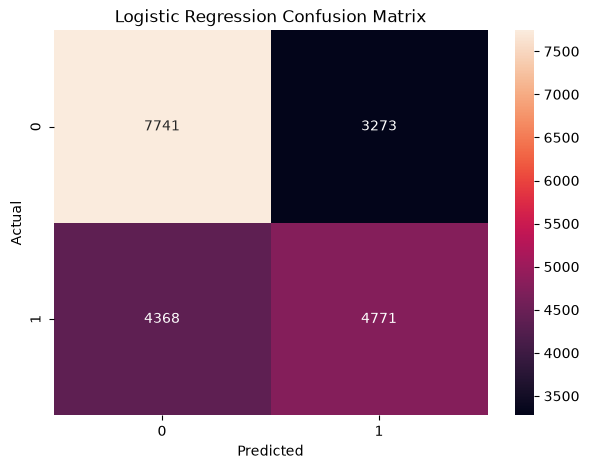

In [31]:
cm = confusion_matrix(
    y_test,
    y_pred_logistic
)

plt.figure(
    figsize=(7, 5)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()

In [32]:
random_forest_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                n_jobs=-1,
                class_weight="balanced"
            )
        )
    ]
)

In [33]:
print(
    "Training Random Forest..."
)

random_forest_model.fit(
    X_train,
    y_train
)

print(
    "Training completed."
)

Training Random Forest...
Training completed.


In [34]:
y_pred_rf = (
    random_forest_model.predict(
        X_test
    )
)

y_prob_rf = (
    random_forest_model.predict_proba(
        X_test
    )[:, 1]
)

In [35]:
rf_metrics = {
    "Model": "Random Forest",

    "Accuracy": accuracy_score(
        y_test,
        y_pred_rf
    ),

    "Precision": precision_score(
        y_test,
        y_pred_rf
    ),

    "Recall": recall_score(
        y_test,
        y_pred_rf
    ),

    "F1": f1_score(
        y_test,
        y_pred_rf
    ),

    "ROC_AUC": roc_auc_score(
        y_test,
        y_prob_rf
    )
}

rf_metrics

{'Model': 'Random Forest',
 'Accuracy': 0.6240758199771747,
 'Precision': 0.5859452325965028,
 'Recall': 0.582995951417004,
 'F1': 0.5844668714348399,
 'ROC_AUC': 0.6732782057583985}

In [36]:
xgb_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            xgb.XGBClassifier(
                n_estimators=200,
                max_depth=6,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                eval_metric="logloss"
            )
        )
    ]
)

In [37]:
print(
    "Training XGBoost..."
)

xgb_model.fit(
    X_train,
    y_train
)

print(
    "Training completed."
)

Training XGBoost...
Training completed.


In [38]:
y_pred_xgb = (
    xgb_model.predict(
        X_test
    )
)

y_prob_xgb = (
    xgb_model.predict_proba(
        X_test
    )[:, 1]
)

In [39]:
xgb_metrics = {
    "Model": "XGBoost",

    "Accuracy": accuracy_score(
        y_test,
        y_pred_xgb
    ),

    "Precision": precision_score(
        y_test,
        y_pred_xgb
    ),

    "Recall": recall_score(
        y_test,
        y_pred_xgb
    ),

    "F1": f1_score(
        y_test,
        y_pred_xgb
    ),

    "ROC_AUC": roc_auc_score(
        y_test,
        y_prob_xgb
    )
}

xgb_metrics

{'Model': 'XGBoost',
 'Accuracy': 0.6451148712350518,
 'Precision': 0.6285418553499806,
 'Recall': 0.5315680052522158,
 'F1': 0.5760018970832346,
 'ROC_AUC': 0.6986123391822359}

In [41]:
model_results = pd.DataFrame(
    [
        logistic_metrics,
        rf_metrics,
        xgb_metrics
    ]
)

model_results


model_results.sort_values(
    by="ROC_AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
2,XGBoost,0.645115,0.628542,0.531568,0.576002,0.698612
1,Random Forest,0.624076,0.585945,0.582996,0.584467,0.673278
0,Logistic Regression,0.620850,0.593113,0.522048,0.555316,0.657234


<Figure size 800x600 with 0 Axes>

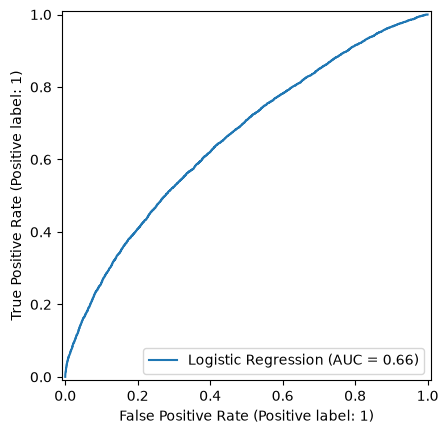

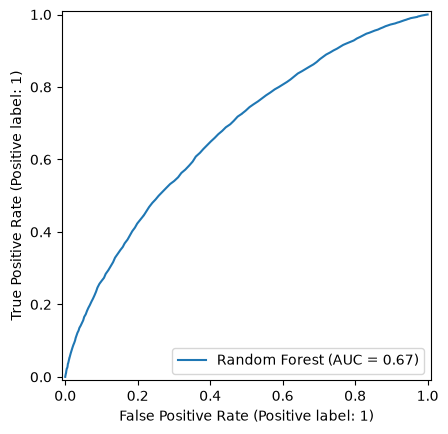

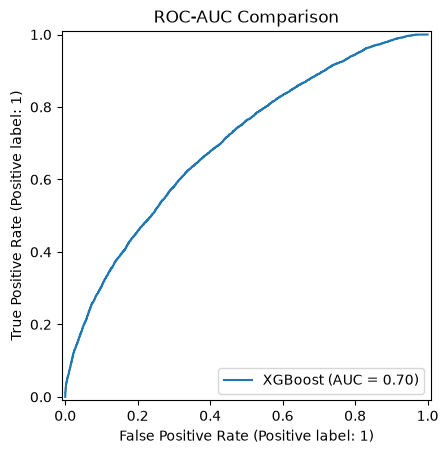

In [42]:
plt.figure(
    figsize=(8, 6)
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_logistic,
    name="Logistic Regression"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf,
    name="Random Forest"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_xgb,
    name="XGBoost"
)

plt.title(
    "ROC-AUC Comparison"
)

plt.show()

In [43]:
RESULTS_DIR = (
    BASE_DIR
    / "Results"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

model_results.to_csv(
    RESULTS_DIR
    / "readmission_model_results.csv",
    index=False
)

print(
    "Model results saved successfully."
)

Model results saved successfully.


In [44]:
best_model_name = (
    model_results
    .sort_values(
        by="ROC_AUC",
        ascending=False
    )
    .iloc[0]["Model"]
)

print(
    "Best model:",
    best_model_name
)

Best model: XGBoost


In [45]:
models = {
    "Logistic Regression": logistic_model,
    "Random Forest": random_forest_model,
    "XGBoost": xgb_model
}

best_model = models[
    best_model_name
]

In [46]:
MODELS_DIR = (
    BASE_DIR
    / "Models"
)

MODELS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MODEL_PATH = (
    MODELS_DIR
    / "readmission_model.pkl"
)

joblib.dump(
    best_model,
    MODEL_PATH
)

print(
    f"Best model saved to:\n{MODEL_PATH}"
)

Best model saved to:
c:\Users\Sai\Documents\HealthSense_AI\Models\readmission_model.pkl
